In [22]:
from  langchain_openai import ChatOpenAI
import os 
from dotenv import load_dotenv

# This function will load all the variables from the .env file and will 
# make them available in the os.environ dictionary (env variables)
load_dotenv() 

if os.environ.get("OPENAI_API_KEY"):
    print("Bro API KEY Variable exists")
else:
    raise ValueError("OPENAI_API_KEY not found")

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

llm_openai = ChatOpenAI(model="gpt-5-mini",temperature=0)

Bro API KEY Variable exists


In [ ]:
# Tool 1 News search tool
from langchain_community.tools import DuckDuckGoSearchRun
search_tools = DuckDuckGoSearchRun(description="This is a tool to search the web for news")


# TOOL - 2 [Wikipedia Search Tool]

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(),description="This is a tool to search Wikipedia")


# TOOL - 3 [Custom Enterprise Tool]

from langchain.tools import tool

@tool
def enterprise_tool(query: str)-> str:
    """This is tool to send emails to employees"""


    return "email sent"



In [17]:
ToolKit = [search_tools, wikipedia_tool, enterprise_tool]
ToolKit

[DuckDuckGoSearchRun(description='This is a tool to search the web for news', api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(description='This is a tool to search Wikipedia', api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'f:\\langchain_proj\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 StructuredTool(name='enterprise_tool', description='This is tool to send emails to employees', args_schema=<class 'langchain_core.utils.pydantic.enterprise_tool'>, func=<function enterprise_tool at 0x000001FB39DF0040>)]

# ReAct Agent

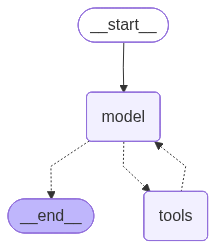

In [18]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="gpt-5-mini",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
)
agent = create_agent(model, tools=ToolKit)
agent

# ReAct Agent Invoke with streams

In [20]:
example_query = "Give me the latest news about the stock market"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Give me the latest news about the stock market
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_SvTUqiuioxiPWKYw5l8dGwHL)
 Call ID: call_SvTUqiuioxiPWKYw5l8dGwHL
  Args:
    query: stock market latest news February 27 2026
================================= Tool Message =================================
Name: duckduckgo_search

11 hours ago · Daily Market Coverage Feb. 26, 2026 9AM-11AM (ET) | Yahoo Finance US stocks split at the opening bell on Thursday as Nvidia's (NVDA) stellar earnings failed ... 6 hours ago · Feb 27 Inferred trading implications: Mean-reversion is dominating this market. That's shown by the frequent reversals we've had on the intra-day charts ... 11 hours ago · Thursday, February 26, 2026: Cramer says the best time to buy this tech stock is at the end of the trading day · Share Article via Facebook · Share Article v

# Manually Bindind LLM with Tools

In [23]:
# without binding
llm_openai.invoke("What is the latest news about the stock market")

AIMessage(content='I can’t fetch live internet data, so I can’t give real-time headlines. I can, however, help in a few ways — tell me which you prefer:\n\n- If you want immediate live headlines: I can point you to the fastest sources and show how to get a quick market snapshot (websites, apps, tickers and APIs).\n- If you want analysis: paste a headline, link, or a set of tickers and I’ll explain what it means and likely market implications.\n- If you want a regular briefing: I can set up a template/watchlist you can use to get fast updates from news feeds or your broker.\n\nQuick guidance so you can get the latest now\n- Fast news sites/apps: Bloomberg, Reuters, CNBC, Financial Times, Wall Street Journal (WSJ). \n- Quick market snapshots: Google Finance, Yahoo Finance, TradingView. Check S&P 500, Dow, Nasdaq, futures (S&P futures for overnight moves), 10-year Treasury yield, VIX.\n- Mobile/broker apps: Robinhood/Schwab/WeBull/Fidelity/Interactive Brokers for real-time quotes and aler

In [25]:
# with binding
llm_binded = llm_openai.bind_tools(ToolKit)
llm_binded.invoke("What is the latest news about the stock market")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 199, 'total_tokens': 314, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DDiQwPcAPff2hA794EefaAEjJJ8Ui', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c9d0d-9269-7e12-b0b0-421a38479aae-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'stock market latest news February 27 2026 S&P 500 Dow Nasdaq today markets close 2026-02-27'}, 'id': 'call_5MLqutan4fKMQLapqzXpVBoi', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 199, 'output_tokens': 115, 'total_tokens': 314, 'input_token_details': {'audio': 0, 